<a href="https://colab.research.google.com/github/sumitkharayat/Machine-learning-work/blob/main/House%20price%20prediction%20on%20Melbourne%20housing%20Lasso(L1)%20and%20Ridge(L2)%20regression%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Applied ML lab/Experiment 11-12/dataset_Melbourne_housing_FULL_exp_12.csv')
print(df.head())

       Suburb             Address  Rooms Type      Price Method SellerG  \
0  Abbotsford       68 Studley St      2    h        NaN     SS  Jellis   
1  Abbotsford        85 Turner St      2    h  1480000.0      S  Biggin   
2  Abbotsford     25 Bloomburg St      2    h  1035000.0      S  Biggin   
3  Abbotsford  18/659 Victoria St      3    u        NaN     VB  Rounds   
4  Abbotsford        5 Charles St      3    h  1465000.0     SP  Biggin   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/09/2016       2.5    3067.0  ...       1.0  1.0     126.0           NaN   
1  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
2  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
3  4/02/2016       2.5    3067.0  ...       2.0  1.0       0.0           NaN   
4  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   

   YearBuilt         CouncilArea Lattitude  Longtitude             R

Data Preprocessing

In [ ]:
df = df.dropna()

X = df.drop("Price", axis=1)
y = df["Price"]

# Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model implementation

In [ ]:
#L1
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

#L2
ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)



Evaluation

In [ ]:
results = []

def evaluate(name, y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print("MSE:", mse)
    print("R2 Score:", r2)

    results.append({
        "Model": name,
        "MSE": mse,
        "R2 Score": r2
    })

evaluate("Lasso", y_test, y_pred_lasso)
evaluate("Ridge", y_test, y_pred_ridge)


Lasso
MSE: 161700906121.98108
R2 Score: 0.5791355561267229

Ridge
MSE: 132674233520.58539
R2 Score: 0.6546842633965669


Visualisation


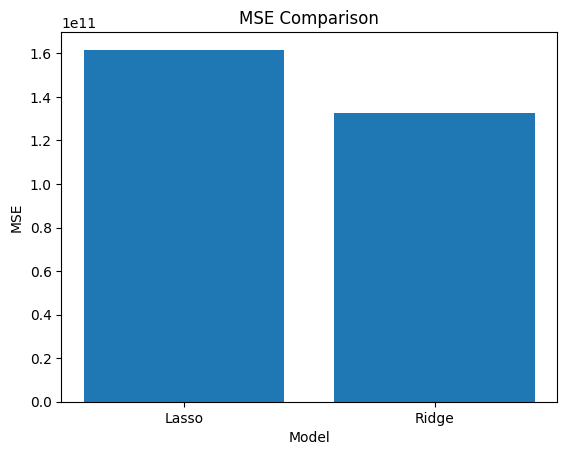

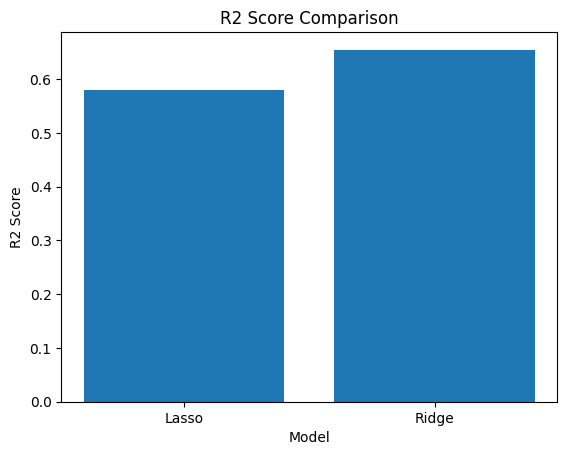

In [ ]:

results_df = pd.DataFrame(results)

# MSE Comparison
plt.figure()
plt.bar(results_df["Model"], results_df["MSE"])
plt.title("MSE Comparison")
plt.xlabel("Model")
plt.ylabel("MSE")
plt.show()

# R2 Score Comparison
plt.figure()
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("R2 Score Comparison")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.show()